In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract
import re
from pytesseract import Output
from skimage.filters import threshold_otsu
from PIL import Image

In [2]:
def plot_image(image, cmap='gray', title='Image'):
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.show()


In [3]:
def clean_string(value):
    return re.sub(r'[^A-Z ]', '', value.upper()).strip()

In [4]:
def extract_name(value):
    return ' '.join(re.findall(r'[A-Z]+', value)).strip()

In [5]:
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)
    if lines is not None:
        angles = [np.arctan2(y2-y1, x2-x1) for [[x1, y1, x2, y2]] in lines]
        median_angle = np.median(angles)
        (h, w) = image.shape[:2]
        center = (w//2, h//2)
        M = cv2.getRotationMatrix2D(center, np.degrees(median_angle), 1.0)
        image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return image

In [6]:
def correct_inversion(image):
    if np.mean(image) > 127:  # Detect if image is inverted
        image = cv2.bitwise_not(image)
    return image


In [7]:
def extract_details(text_list):
    user_details = {}
    for idx, ele in enumerate(text_list):
        if re.search('Permanent|Account|Number|Card', ele):
            pan_match = re.search(r'[A-Z]{5}[0-9]{4}[A-Z]', text_list[idx + 1])
            if pan_match:
                user_details["PAN_Number"] = pan_match.group(0)
        elif re.search("Father|Father's|Name", ele):
            user_details["FatherName"] = extract_name(text_list[idx + 1])
            user_details["Name"] = extract_name(text_list[idx - 1])
        if match := re.search(r'\d{2}/\d{2}/\d{4}', ele):
            user_details["DOB"] = match.group(0)
    return user_details


In [8]:
def extract_details_format2(text_list):
    user_details = {}
    for idx, ele in enumerate(text_list):
        if re.search('Permanent|Account|Number|Card', ele):
            pan_match = re.search(r'[A-Z]{5}[0-9]{4}[A-Z]', text_list[idx + 1])
            if pan_match:
                user_details["PAN_Number"] = pan_match.group(0)
        if match := re.search(r'\d{2}/\d{2}/\d{4}', ele):
            user_details["DOB"] = match.group(0)
            user_details["FatherName"] = extract_name(text_list[idx - 1])
            user_details["Name"] = extract_name(text_list[idx - 2])
    return user_details



In [9]:
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh_val = threshold_otsu(gray)
    mask = np.where(gray > thresh_val, 1, 0)
    img = (mask * 255).astype(np.uint8)
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened = cv2.filter2D(img, -1, sharpen_kernel)
    kernel = np.ones((2,2), np.uint8)
    processed = cv2.dilate(cv2.erode(sharpened, kernel, iterations=1), kernel, iterations=1)
    return processed

In [10]:
def extract_text(image):
    return pytesseract.image_to_string(image).strip().split("\n")

In [11]:
def detect_text(image):
    d = pytesseract.image_to_data(image, output_type=Output.DICT)
    boxes = cv2.cvtColor(image.copy(), cv2.COLOR_GRAY2BGR)
    for x, y, w, h in zip(d['left'], d['top'], d['width'], d['height']):
        cv2.rectangle(boxes, (x, y), (x + w, y + h), (0, 0, 255), 2)
    plot_image(boxes, cmap='gray', title='Detected Text')


In [12]:
def process_pan_card(image):
    deskewed_img = deskew(image)
    plot_image(deskewed_img, cmap='gray', title='Deskewed Image')
    
    processed_img = preprocess_image(deskewed_img)
    plot_image(processed_img, cmap='gray', title='Processed Image')
    
    extracted_text = extract_text(processed_img)
    extracted_text = [ele for ele in extracted_text if ele.strip()]
    
    for ele in extracted_text:
        if re.search('Permanent|Account|Number|Card', ele):
            if re.search(r'\d{2}/\d{2}/\d{4}', extracted_text[extracted_text.index(ele)-1].strip()):
                print("Card format: Labels absent")
                print(extract_details_format2(extracted_text))
            else:
                print("Card format: Labels present")
                print(extract_details(extracted_text))
    detect_text(processed_img)



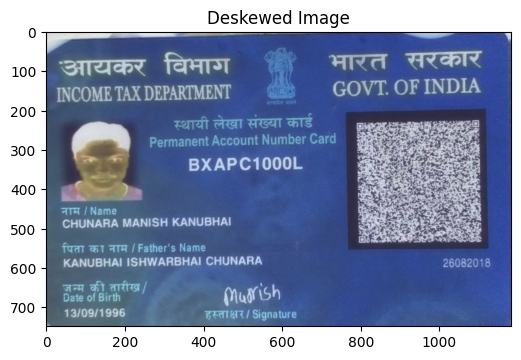

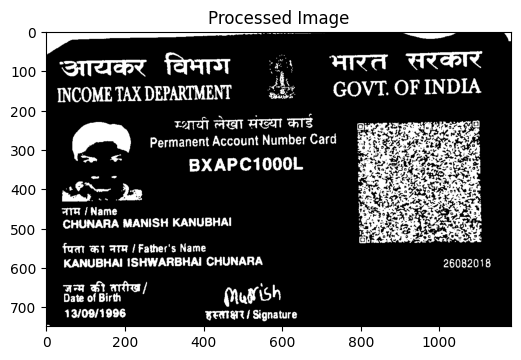

Card format: Labels present
{'FatherName': 'KANUBHAI ISHWARBHAI CHUNARA', 'Name': 'CHUNARA MANISH KANUBHAI', 'DOB': '13/09/1996'}


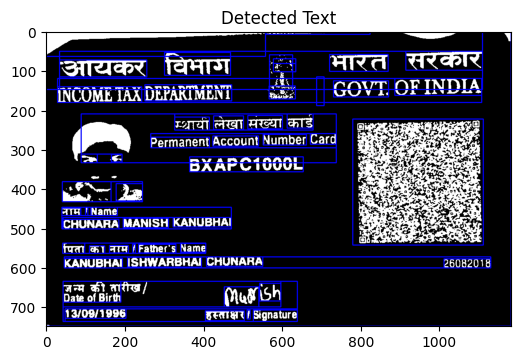

In [13]:
image = cv2.imread("pancard/3.png")
image=cv2.bitwise_not(image)
process_pan_card(image)